# Job Recommendation System
## Step 7: Evaluate the Recommendations

**Internship Project** | Gamage Recruiters  
**Focus:** Recruitment & HR / Data Science & Machine Learning  

---

This notebook evaluates the recommendation quality of all five similarity metrics produced in Step 6.  
Since no historical application / click data was collected, we use **domain match** as a proxy for relevance — a job is considered relevant to a candidate if its `industry` matches the candidate's `primary_domain`.

### Evaluation Metrics
| Metric | Formula | Interpretation |
|---|---|---|
| **Precision@K** | (relevant in top-K) / K | What fraction of the K recommendations were relevant? |
| **Recall@K** | (relevant in top-K) / (total relevant jobs) | What fraction of all relevant jobs did we surface? |
| **F1@K** | 2 × P@K × R@K / (P@K + R@K) | Harmonic mean of Precision and Recall |
| **MAP** | mean of Average Precision across candidates | Overall ranking quality summary |
| **NDCG@K** | Normalised Discounted Cumulative Gain | Rewards relevant items appearing earlier in the list |
| **Hit Rate@K** | % candidates with ≥1 relevant job in top-K | At least one good recommendation |

### Metrics Compared
- TF-IDF Cosine
- Word2Vec Cosine
- Euclidean Similarity
- Pearson Similarity
- **Hybrid Score** (recommended)


## 1. Install & Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

METRIC_COLORS = {
    'hybrid':    '#1565C0',   # deep blue
    'tfidf':     '#2196F3',   # blue
    'w2v':       '#9C27B0',   # purple
    'euclidean': '#4CAF50',   # green
    'pearson':   '#FF9800',   # orange
}
METRIC_LABELS = {
    'hybrid':    'Hybrid Score',
    'tfidf':     'TF-IDF Cosine',
    'w2v':       'Word2Vec Cosine',
    'euclidean': 'Euclidean Sim',
    'pearson':   'Pearson Sim',
}

os.makedirs('../outputs', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 2. Load Outputs from Previous Steps

In [5]:
# ── Candidate & Job DataFrames ──────────────────────────────────────────────
df_c = pd.read_csv('../data/candidates_preprocessed.csv')
df_j = pd.read_csv('../data/job_postings_preprocessed.csv')

# ── Step-6 recommendations (long format) ───────────────────────────────────
df_recs = pd.read_csv('../outputs/step6_recommendations.csv')

# ── Score matrices (500 candidates × 200 jobs) ─────────────────────────────
score_matrices = {
    'hybrid':    np.load('../models/step6_hybrid_score_matrix.npy'),
    'tfidf':     np.load('../models/step6_tfidf_cosine_matrix.npy'),
    'w2v':       np.load('../models/step6_w2v_cosine_matrix.npy'),
    'euclidean': np.load('../models/step6_euc_sim_matrix.npy'),
    'pearson':   np.load('../models/step6_pearson_sim_matrix.npy'),
}

print(f'Candidates  : {len(df_c):,}')
print(f'Jobs        : {len(df_j):,}')
print(f'Rec rows    : {len(df_recs):,}')
print(f'Matrix shape: {score_matrices["hybrid"].shape}')
print(f'\nCandidate columns : {list(df_c.columns)}')
print(f'Job columns       : {list(df_j.columns)}')

Candidates  : 500
Jobs        : 200
Rec rows    : 2,500
Matrix shape: (500, 200)

Candidate columns : ['candidate_id', 'name', 'email', 'phone', 'location', 'education_level', 'university', 'field_of_study', 'years_of_experience', 'experience_level', 'primary_domain', 'skills', 'preferred_locations', 'preferred_job_types', 'summary', 'skills_clean', 'summary_clean', 'combined_text', 'experience_encoded', 'education_encoded', 'domain_encoded', 'experience_normalized']
Job columns       : ['job_id', 'job_title', 'company_name', 'industry', 'location', 'job_type', 'experience_level', 'min_experience_years', 'education_required', 'required_skills', 'preferred_skills', 'salary_min_lkr', 'salary_max_lkr', 'posted_date', 'description', 'required_skills_clean', 'preferred_skills_clean', 'description_clean', 'combined_text', 'experience_encoded', 'edu_required_encoded', 'industry_encoded', 'min_exp_normalized', 'salary_min_norm', 'salary_max_norm', 'salary_mid_norm']


## 3. Build the Relevance Ground-Truth

We define a job as **relevant** to a candidate when the job's `industry` matches the candidate's `primary_domain`.  
This produces a binary relevance matrix (`rel_matrix`) of shape (500 × 200).

In [6]:
# Align index so row i of rel_matrix corresponds to df_c.iloc[i]
df_c = df_c.reset_index(drop=True)
df_j = df_j.reset_index(drop=True)

domains_c = df_c['primary_domain'].values          # shape (500,)
industries_j = df_j['industry'].values             # shape (200,)

# Broadcast: (500,1) == (1,200)  →  (500,200) boolean matrix
rel_matrix = (domains_c[:, None] == industries_j[None, :]).astype(int)

n_candidates, n_jobs = rel_matrix.shape
print(f'Relevance matrix shape : {rel_matrix.shape}')
print(f'Avg relevant jobs per candidate : {rel_matrix.sum(axis=1).mean():.1f}')
print(f'Min / Max relevant jobs         : {rel_matrix.sum(axis=1).min()} / {rel_matrix.sum(axis=1).max()}')

# Sanity-check: show domain distribution
print('\nCandidate domain distribution:')
print(df_c['primary_domain'].value_counts().to_string())

Relevance matrix shape : (500, 200)
Avg relevant jobs per candidate : 40.0
Min / Max relevant jobs         : 31 / 47

Candidate domain distribution:
primary_domain
Technology    105
Operations    103
Marketing     102
Finance        95
HR             95


## 4. Evaluation Functions

In [7]:
def precision_at_k(score_row, rel_row, k):
    """Precision@K for one candidate."""
    top_k = np.argsort(score_row)[::-1][:k]
    return rel_row[top_k].sum() / k


def recall_at_k(score_row, rel_row, k):
    """Recall@K for one candidate."""
    top_k = np.argsort(score_row)[::-1][:k]
    total_relevant = rel_row.sum()
    if total_relevant == 0:
        return 0.0
    return rel_row[top_k].sum() / total_relevant


def f1_at_k(p, r):
    """F1 from Precision and Recall (handles zero denominator)."""
    if (p + r) == 0:
        return 0.0
    return 2 * p * r / (p + r)


def average_precision(score_row, rel_row):
    """Average Precision for one candidate (used for MAP)."""
    ranked_idx = np.argsort(score_row)[::-1]
    ranked_rel = rel_row[ranked_idx]
    hits = 0
    ap_sum = 0.0
    for rank, r in enumerate(ranked_rel, start=1):
        if r == 1:
            hits += 1
            ap_sum += hits / rank
    total_relevant = rel_row.sum()
    if total_relevant == 0:
        return 0.0
    return ap_sum / total_relevant


def ndcg_at_k(score_row, rel_row, k):
    """NDCG@K for one candidate."""
    top_k = np.argsort(score_row)[::-1][:k]
    gains = rel_row[top_k]
    discounts = np.log2(np.arange(2, k + 2))  # log2(2), log2(3), ...
    dcg = (gains / discounts).sum()

    # Ideal DCG: best possible ordering
    ideal_gains = np.sort(rel_row)[::-1][:k]
    idcg = (ideal_gains / discounts[:len(ideal_gains)]).sum()
    if idcg == 0:
        return 0.0
    return dcg / idcg


def hit_rate_at_k(score_row, rel_row, k):
    """1 if at least one relevant job is in top-K, else 0."""
    top_k = np.argsort(score_row)[::-1][:k]
    return int(rel_row[top_k].sum() > 0)


print('Evaluation functions defined.')

Evaluation functions defined.


## 5. Compute All Metrics for Each Similarity Method

In [8]:
K_VALUES = [1, 3, 5, 10]
results = {}   # metric_name -> dict of evaluation scores

for metric_name, score_matrix in score_matrices.items():
    p_at_k   = {k: [] for k in K_VALUES}
    r_at_k   = {k: [] for k in K_VALUES}
    f1_at_k_ = {k: [] for k in K_VALUES}
    ndcg_at_k_ = {k: [] for k in K_VALUES}
    hit_at_k = {k: [] for k in K_VALUES}
    aps = []

    for i in range(n_candidates):
        score_row = score_matrix[i]
        rel_row   = rel_matrix[i]

        for k in K_VALUES:
            p = precision_at_k(score_row, rel_row, k)
            r = recall_at_k(score_row, rel_row, k)
            p_at_k[k].append(p)
            r_at_k[k].append(r)
            f1_at_k_[k].append(f1_at_k(p, r))
            ndcg_at_k_[k].append(ndcg_at_k(score_row, rel_row, k))
            hit_at_k[k].append(hit_rate_at_k(score_row, rel_row, k))

        aps.append(average_precision(score_row, rel_row))

    results[metric_name] = {
        'precision': {k: np.mean(p_at_k[k])   for k in K_VALUES},
        'recall':    {k: np.mean(r_at_k[k])   for k in K_VALUES},
        'f1':        {k: np.mean(f1_at_k_[k]) for k in K_VALUES},
        'ndcg':      {k: np.mean(ndcg_at_k_[k]) for k in K_VALUES},
        'hit_rate':  {k: np.mean(hit_at_k[k]) for k in K_VALUES},
        'MAP':       np.mean(aps),
        # Keep per-candidate arrays for plotting
        '_aps':      aps,
        '_p5':       p_at_k[5],
        '_ndcg5':    ndcg_at_k_[5],
    }

print('Evaluation complete for all metrics.')

Evaluation complete for all metrics.


## 6. Summary Table — All Metrics at K = 5

In [9]:
K = 5
summary_rows = []
for metric_name, res in results.items():
    summary_rows.append({
        'Metric':        METRIC_LABELS[metric_name],
        f'Precision@{K}': round(res['precision'][K], 4),
        f'Recall@{K}':    round(res['recall'][K],    4),
        f'F1@{K}':        round(res['f1'][K],        4),
        f'NDCG@{K}':      round(res['ndcg'][K],      4),
        f'HitRate@{K}':   round(res['hit_rate'][K],  4),
        'MAP':            round(res['MAP'],           4),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('MAP', ascending=False)
df_summary = df_summary.reset_index(drop=True)

# Highlight best values in each column
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #c8e6c9; font-weight: bold' if v else '' for v in is_max]

numeric_cols = [c for c in df_summary.columns if c != 'Metric']
display(df_summary.style.apply(highlight_max, subset=numeric_cols))

# Save CSV
df_summary.to_csv('../outputs/step7_evaluation_summary.csv', index=False)
print('\nSaved: ../outputs/step7_evaluation_summary.csv')

,Metric,Precision@5,Recall@5,F1@5,NDCG@5,HitRate@5,MAP
0,Word2Vec Cosine,1.000000,0.128200,0.226600,1.000000,1.000000,1.000000
1,Hybrid Score,1.000000,0.128200,0.226600,1.000000,1.000000,0.994900
2,TF-IDF Cosine,0.994800,0.127500,0.225400,0.996100,1.000000,0.903000
3,Euclidean Sim,0.994800,0.127500,0.225400,0.996100,1.000000,0.903000
4,Pearson Sim,0.994400,0.127400,0.225300,0.995800,1.000000,0.896000



Saved: ../outputs/step7_evaluation_summary.csv


## 7. Precision@K and Recall@K Across K Values

How does recommendation quality change as we increase the number of recommendations returned?

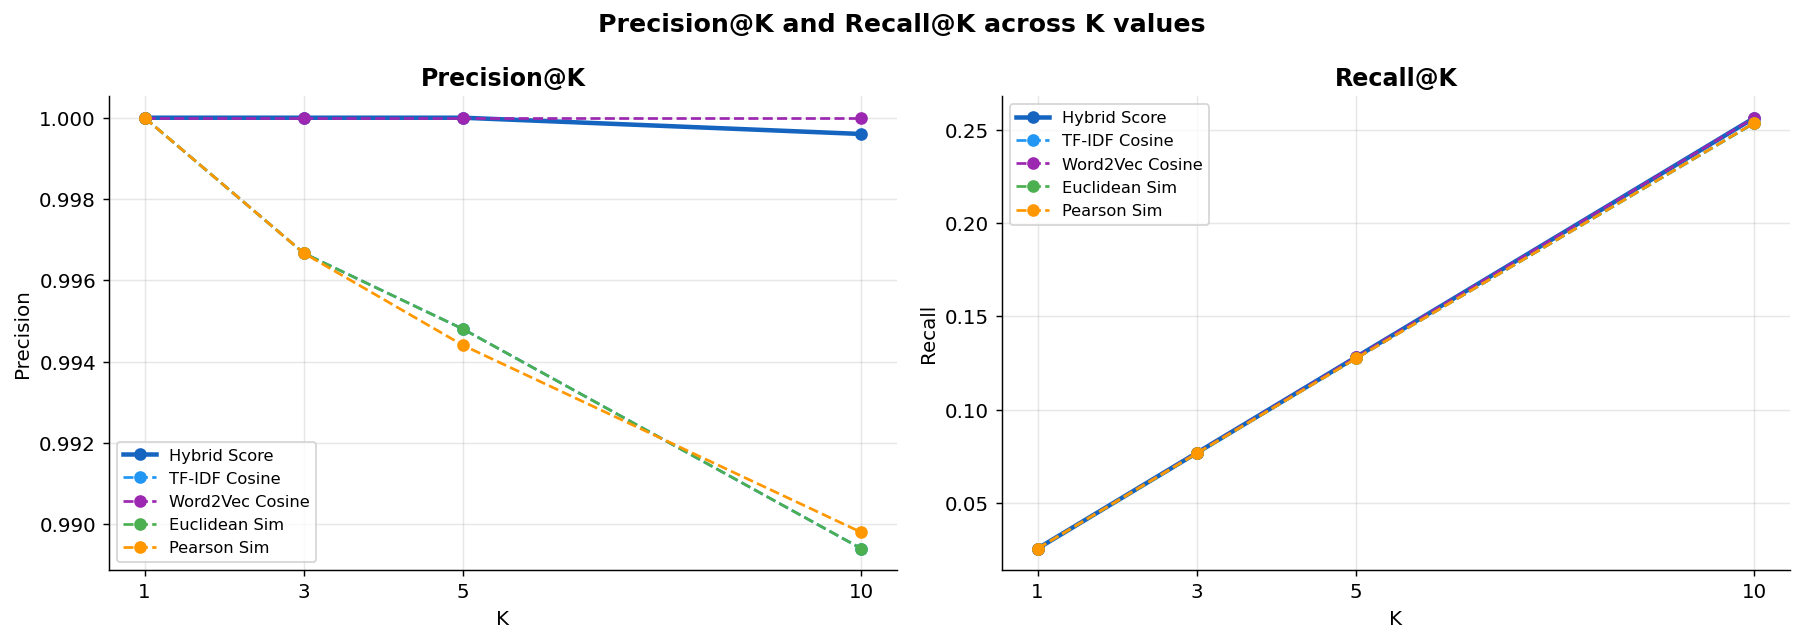

Saved: ../outputs/step7_plot1_precision_recall_at_k.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Precision@K and Recall@K across K values', fontsize=14, fontweight='bold')

for metric_name, res in results.items():
    color = METRIC_COLORS[metric_name]
    label = METRIC_LABELS[metric_name]
    lw    = 2.5 if metric_name == 'hybrid' else 1.5
    ls    = '-'  if metric_name == 'hybrid' else '--'

    p_vals = [res['precision'][k] for k in K_VALUES]
    r_vals = [res['recall'][k]    for k in K_VALUES]

    axes[0].plot(K_VALUES, p_vals, color=color, lw=lw, ls=ls, marker='o', label=label)
    axes[1].plot(K_VALUES, r_vals, color=color, lw=lw, ls=ls, marker='o', label=label)

axes[0].set_title('Precision@K',  fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision')
axes[0].set_xticks(K_VALUES)
axes[0].legend(fontsize=9)

axes[1].set_title('Recall@K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Recall')
axes[1].set_xticks(K_VALUES)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/step7_plot1_precision_recall_at_k.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot1_precision_recall_at_k.png')

## 8. Bar Chart — MAP Comparison Across Metrics

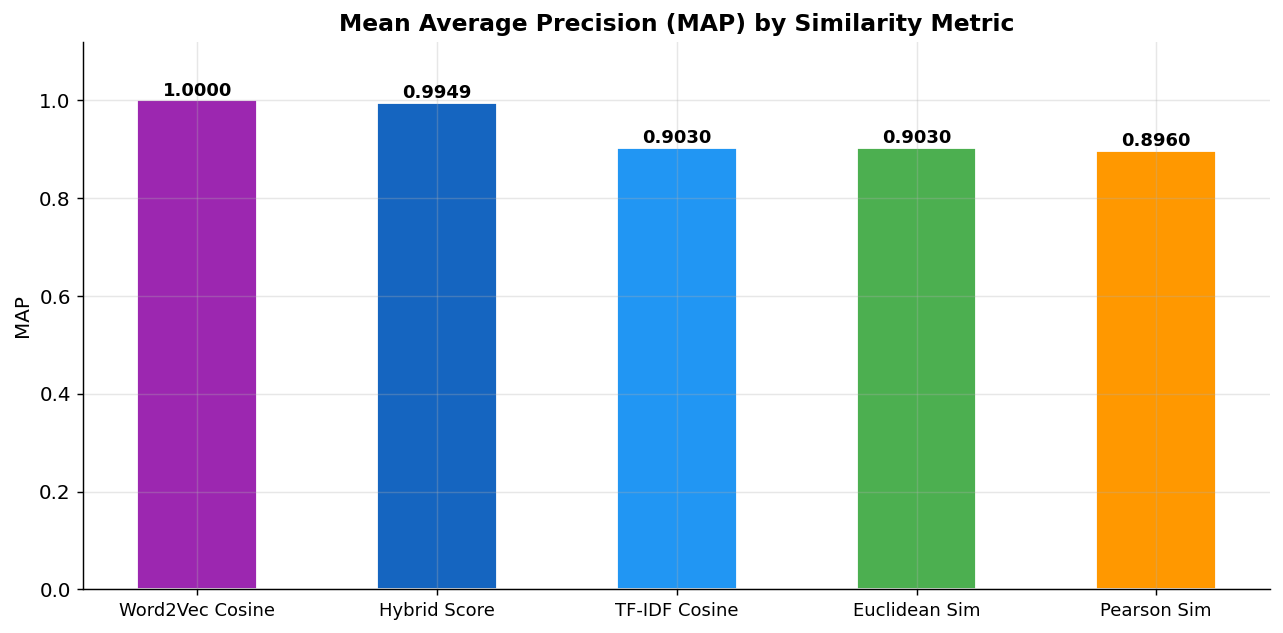

Saved: ../outputs/step7_plot2_map_comparison.png


In [11]:
map_scores = {METRIC_LABELS[m]: results[m]['MAP'] for m in results}
sorted_metrics = sorted(map_scores.items(), key=lambda x: x[1], reverse=True)
labels_sorted, vals_sorted = zip(*sorted_metrics)
colors_sorted = [METRIC_COLORS[m] for m in sorted(results, key=lambda m: results[m]['MAP'], reverse=True)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_sorted, vals_sorted, color=colors_sorted, edgecolor='white', width=0.5)

for bar, val in zip(bars, vals_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Mean Average Precision (MAP) by Similarity Metric', fontsize=13, fontweight='bold')
ax.set_ylabel('MAP')
ax.set_ylim(0, max(vals_sorted) * 1.12)
ax.set_xticklabels(labels_sorted, fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/step7_plot2_map_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot2_map_comparison.png')

## 9. NDCG@K — Ranking Quality

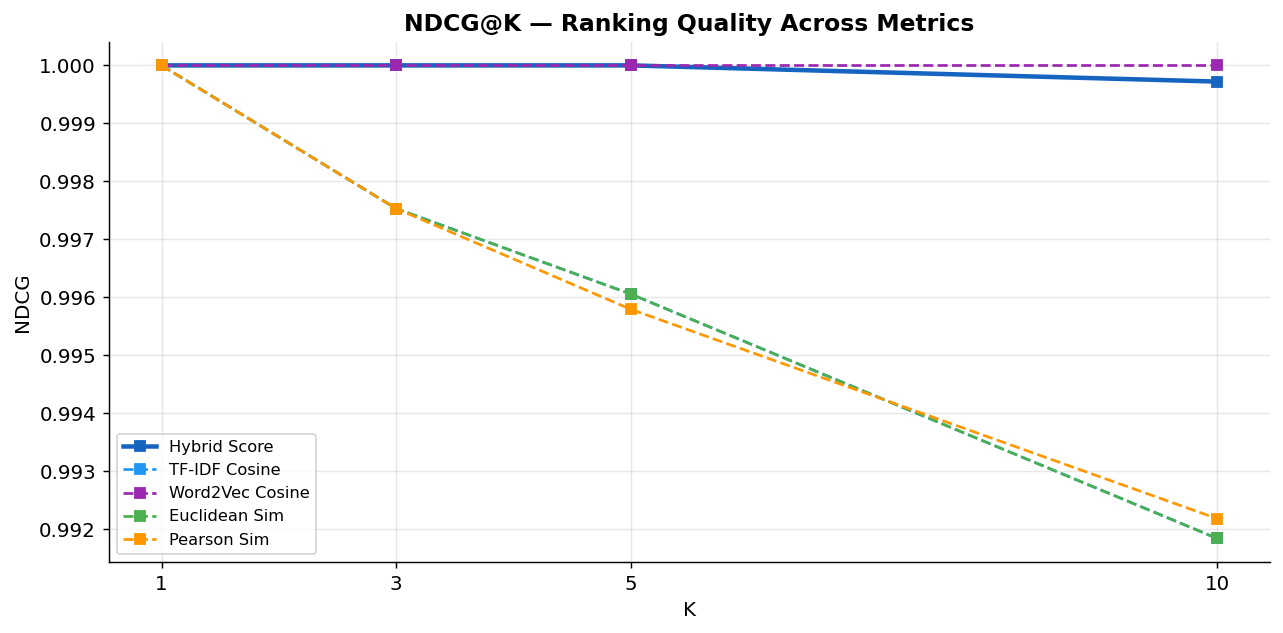

Saved: ../outputs/step7_plot3_ndcg_at_k.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for metric_name, res in results.items():
    ndcg_vals = [res['ndcg'][k] for k in K_VALUES]
    lw = 2.5 if metric_name == 'hybrid' else 1.5
    ls = '-'  if metric_name == 'hybrid' else '--'
    ax.plot(K_VALUES, ndcg_vals, color=METRIC_COLORS[metric_name],
            lw=lw, ls=ls, marker='s', label=METRIC_LABELS[metric_name])

ax.set_title('NDCG@K — Ranking Quality Across Metrics', fontsize=13, fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('NDCG')
ax.set_xticks(K_VALUES)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/step7_plot3_ndcg_at_k.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot3_ndcg_at_k.png')

## 10. Hit Rate@K — What % of Candidates Get at Least One Relevant Job?

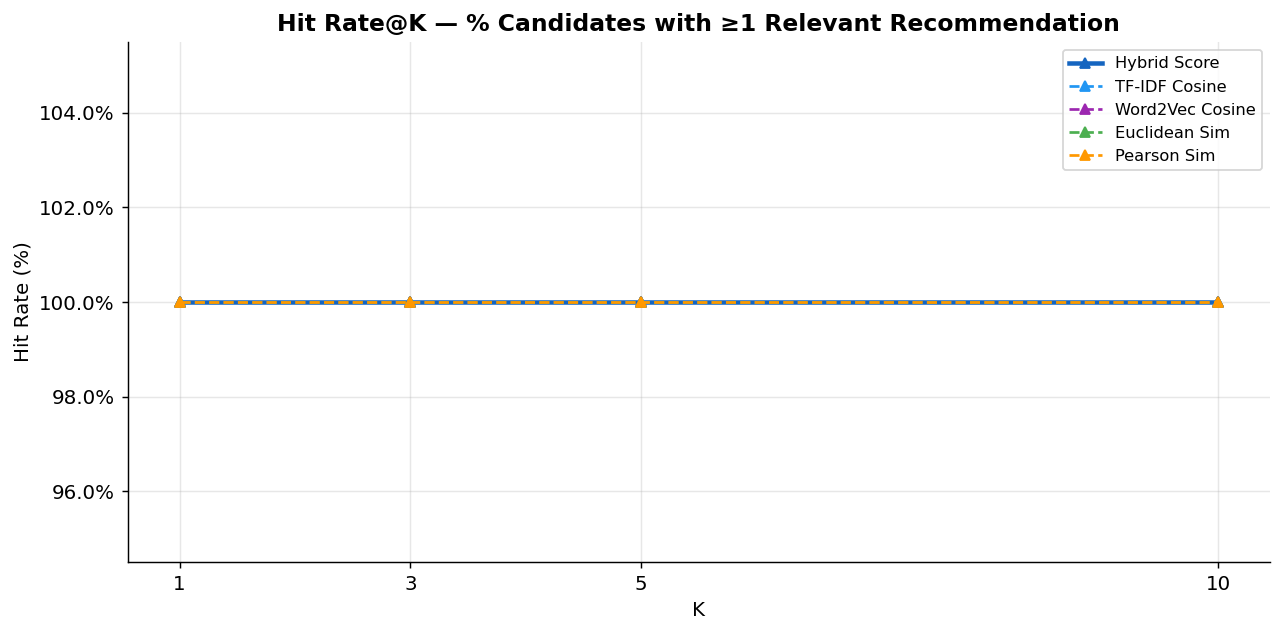

Saved: ../outputs/step7_plot4_hit_rate_at_k.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

for metric_name, res in results.items():
    hit_vals = [res['hit_rate'][k] * 100 for k in K_VALUES]   # convert to %
    lw = 2.5 if metric_name == 'hybrid' else 1.5
    ls = '-'  if metric_name == 'hybrid' else '--'
    ax.plot(K_VALUES, hit_vals, color=METRIC_COLORS[metric_name],
            lw=lw, ls=ls, marker='^', label=METRIC_LABELS[metric_name])

ax.set_title('Hit Rate@K — % Candidates with ≥1 Relevant Recommendation', fontsize=13, fontweight='bold')
ax.set_xlabel('K')
ax.set_ylabel('Hit Rate (%)')
ax.set_xticks(K_VALUES)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/step7_plot4_hit_rate_at_k.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot4_hit_rate_at_k.png')

## 11. Per-Candidate AP Distribution (Box Plots)

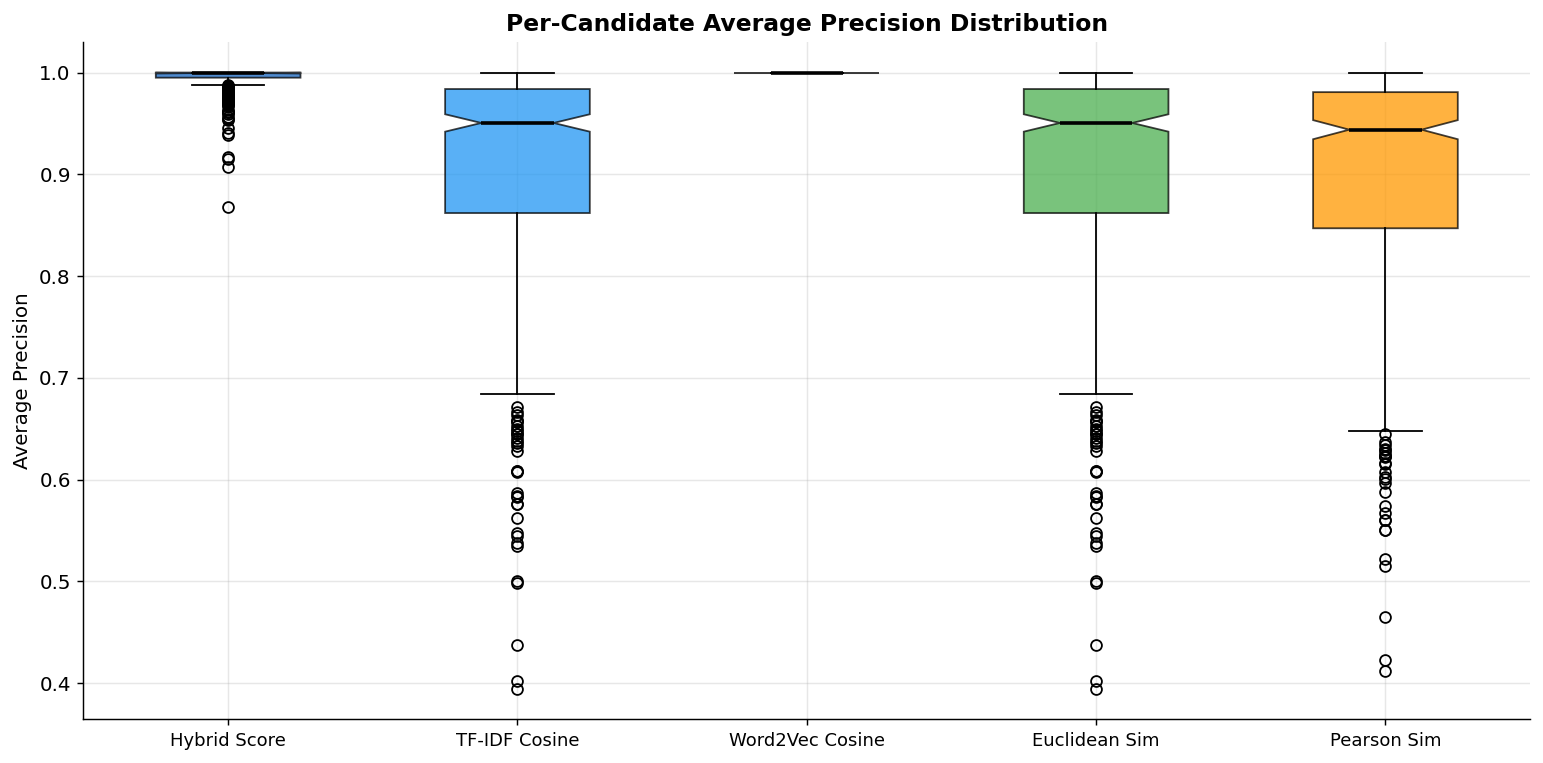

Saved: ../outputs/step7_plot5_ap_distribution.png


In [14]:
ap_data = {
    METRIC_LABELS[m]: results[m]['_aps']
    for m in results
}

fig, ax = plt.subplots(figsize=(12, 6))
positions = range(1, len(ap_data) + 1)
bp = ax.boxplot(
    list(ap_data.values()),
    patch_artist=True,
    notch=True,
    medianprops=dict(color='black', lw=2),
)

colors_order = [METRIC_COLORS[m] for m in results]
for patch, color in zip(bp['boxes'], colors_order):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(list(positions))
ax.set_xticklabels(list(ap_data.keys()), fontsize=10)
ax.set_title('Per-Candidate Average Precision Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Precision')

plt.tight_layout()
plt.savefig('../outputs/step7_plot5_ap_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot5_ap_distribution.png')

## 12. Heatmap — All Evaluation Metrics Across K Values

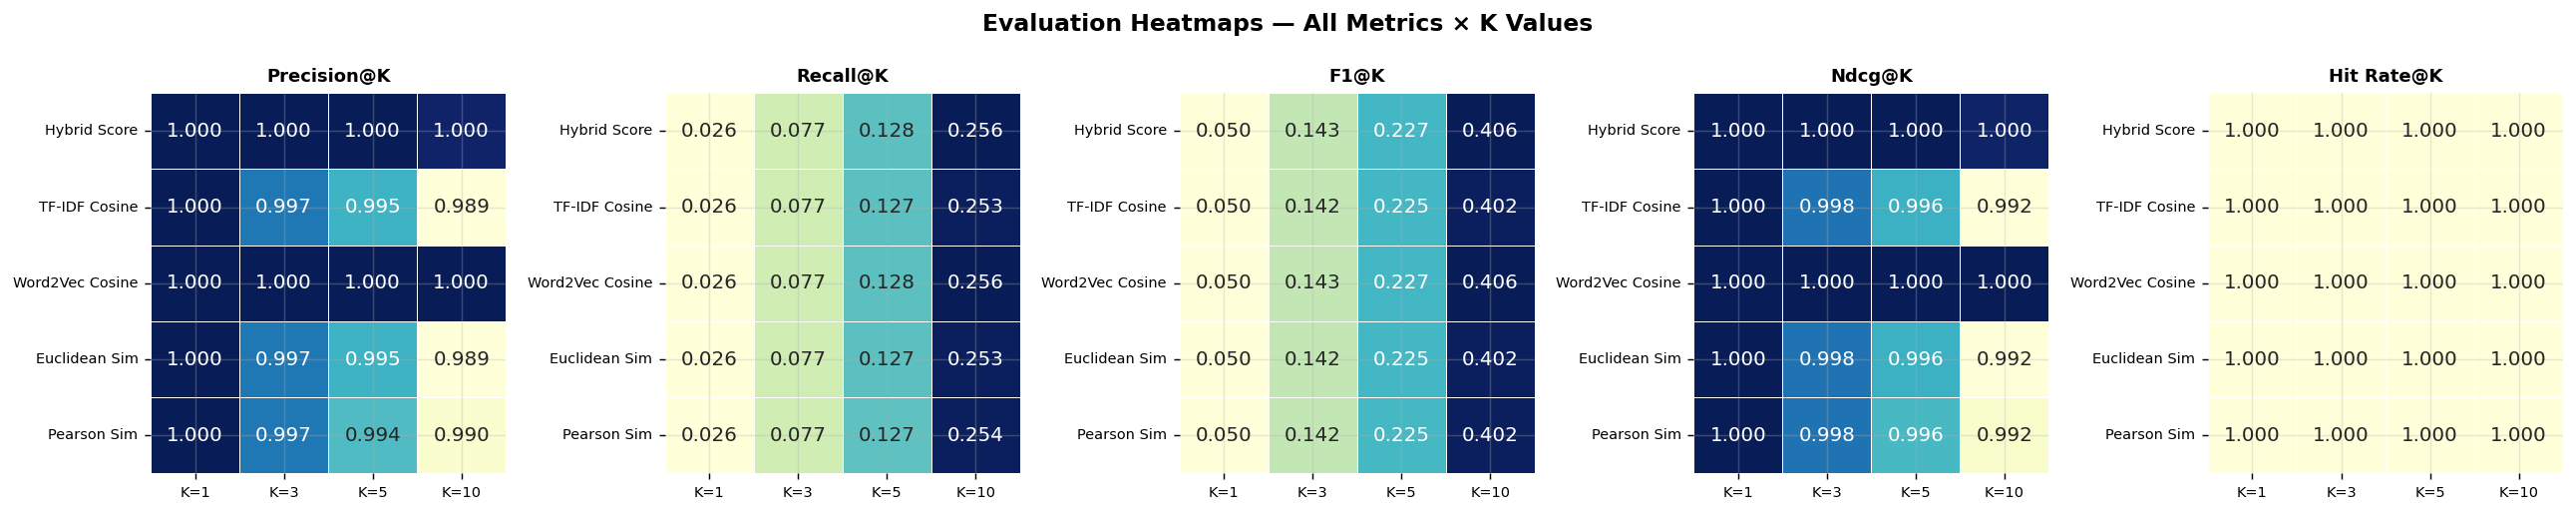

Saved: ../outputs/step7_plot6_evaluation_heatmap.png


In [15]:
eval_names = ['precision', 'recall', 'f1', 'ndcg', 'hit_rate']

fig, axes = plt.subplots(1, len(eval_names), figsize=(20, 4))
fig.suptitle('Evaluation Heatmaps — All Metrics × K Values', fontsize=13, fontweight='bold')

for ax, eval_name in zip(axes, eval_names):
    heat_data = []
    row_labels = []
    for m in ['hybrid', 'tfidf', 'w2v', 'euclidean', 'pearson']:
        heat_data.append([results[m][eval_name][k] for k in K_VALUES])
        row_labels.append(METRIC_LABELS[m])

    heat_df = pd.DataFrame(heat_data, index=row_labels, columns=[f'K={k}' for k in K_VALUES])
    sns.heatmap(heat_df, ax=ax, annot=True, fmt='.3f', cmap='YlGnBu',
                cbar=False, linewidths=0.5)
    ax.set_title(eval_name.replace('_', ' ').title() + '@K', fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../outputs/step7_plot6_evaluation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot6_evaluation_heatmap.png')

## 13. Per-Domain Evaluation (Precision@5)

Do some candidate domains benefit more from the recommendation system?

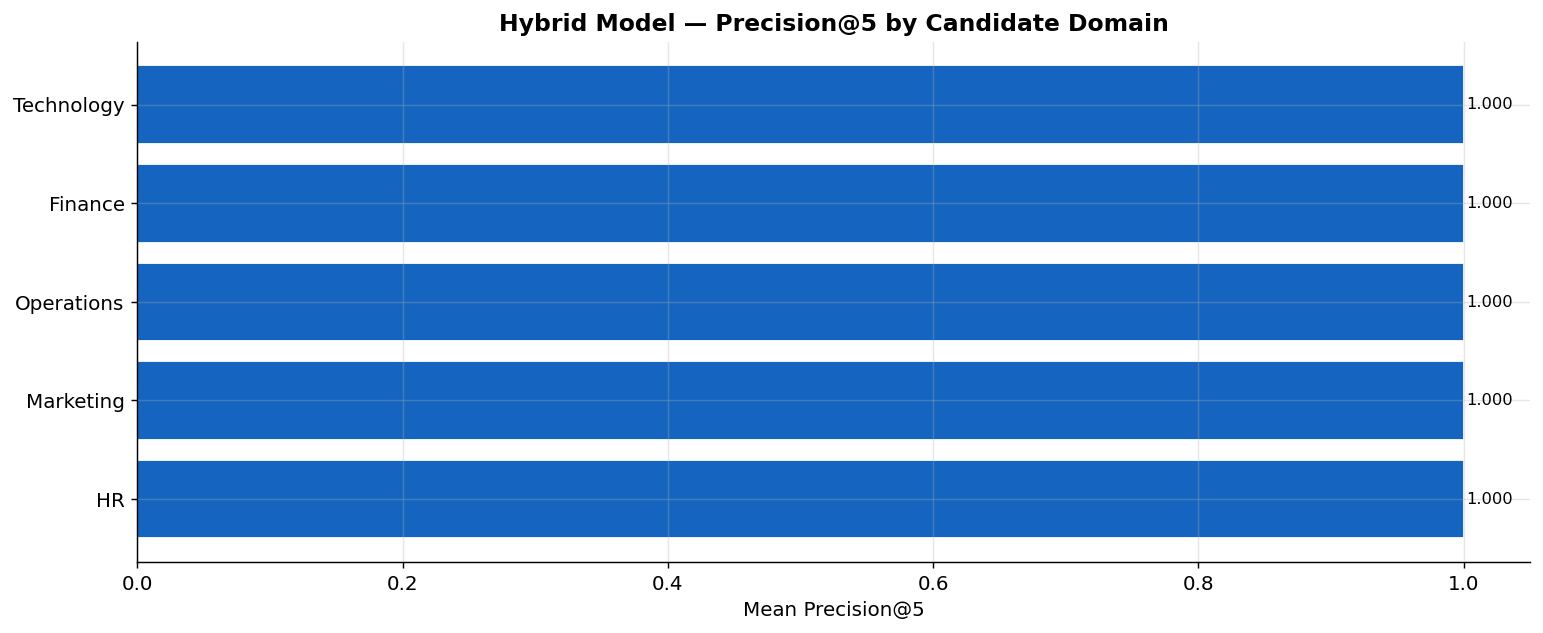

Saved: ../outputs/step7_plot7_domain_precision.png


In [16]:
K = 5
domains = df_c['primary_domain'].unique()
domain_results = {m: {} for m in results}

for domain in domains:
    domain_idx = df_c[df_c['primary_domain'] == domain].index.tolist()
    for metric_name, score_matrix in score_matrices.items():
        ps = []
        for i in domain_idx:
            ps.append(precision_at_k(score_matrix[i], rel_matrix[i], K))
        domain_results[metric_name][domain] = np.mean(ps)

# Plot only Hybrid for clarity (most informative)
domain_p5 = domain_results['hybrid']
sorted_domains = sorted(domain_p5.items(), key=lambda x: x[1], reverse=True)
d_labels, d_vals = zip(*sorted_domains)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(d_labels, d_vals, color='#1565C0', edgecolor='white')
for bar, val in zip(bars, d_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title(f'Hybrid Model — Precision@{K} by Candidate Domain', fontsize=13, fontweight='bold')
ax.set_xlabel(f'Mean Precision@{K}')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/step7_plot7_domain_precision.png', bbox_inches='tight')
plt.show()
print('Saved: ../outputs/step7_plot7_domain_precision.png')

## 14. Detailed Evaluation Table — All K Values

In [17]:
rows = []
for metric_name, res in results.items():
    for k in K_VALUES:
        rows.append({
            'Metric':     METRIC_LABELS[metric_name],
            'K':          k,
            'Precision':  round(res['precision'][k], 4),
            'Recall':     round(res['recall'][k],    4),
            'F1':         round(res['f1'][k],        4),
            'NDCG':       round(res['ndcg'][k],      4),
            'HitRate':    round(res['hit_rate'][k],  4),
            'MAP':        round(res['MAP'],           4),
        })

df_detailed = pd.DataFrame(rows)
df_detailed.to_csv('../outputs/step7_evaluation_detailed.csv', index=False)
print('Shape:', df_detailed.shape)
display(df_detailed.sort_values(['K', 'MAP'], ascending=[True, False]))
print('Saved: ../outputs/step7_evaluation_detailed.csv')

Shape: (20, 8)


,Metric,K,Precision,Recall,F1,NDCG,HitRate,MAP
8,Word2Vec Cosine,1,1.0000,0.0256,0.0499,1.0000,1.0,1.0000
0,Hybrid Score,1,1.0000,0.0256,0.0499,1.0000,1.0,0.9949
4,TF-IDF Cosine,1,1.0000,0.0256,0.0499,1.0000,1.0,0.9030
12,Euclidean Sim,1,1.0000,0.0256,0.0499,1.0000,1.0,0.9030
16,Pearson Sim,1,1.0000,0.0256,0.0499,1.0000,1.0,0.8960
9,Word2Vec Cosine,3,1.0000,0.0769,0.1426,1.0000,1.0,1.0000
1,Hybrid Score,3,1.0000,0.0769,0.1426,1.0000,1.0,0.9949
5,TF-IDF Cosine,3,0.9967,0.0766,0.1421,0.9975,1.0,0.9030
13,Euclidean Sim,3,0.9967,0.0766,0.1421,0.9975,1.0,0.9030
17,Pearson Sim,3,0.9967,0.0766,0.1421,0.9975,1.0,0.8960


Saved: ../outputs/step7_evaluation_detailed.csv


## 15. Save Evaluation Results for the Step 8 Dashboard

In [18]:
import json

# Serialise results (excluding numpy arrays) for dashboard use
eval_export = {}
for metric_name, res in results.items():
    eval_export[metric_name] = {
        'precision': {str(k): v for k, v in res['precision'].items()},
        'recall':    {str(k): v for k, v in res['recall'].items()},
        'f1':        {str(k): v for k, v in res['f1'].items()},
        'ndcg':      {str(k): v for k, v in res['ndcg'].items()},
        'hit_rate':  {str(k): v for k, v in res['hit_rate'].items()},
        'MAP':       float(res['MAP']),
        'label':     METRIC_LABELS[metric_name],
        'color':     METRIC_COLORS[metric_name],
    }

with open('../outputs/step7_eval_results.json', 'w') as f:
    json.dump(eval_export, f, indent=2)

print('Saved: ../outputs/step7_eval_results.json')
print()
print('Step 7 complete! All outputs saved to ../outputs/')
print()
print('Files produced:')
for fname in sorted(os.listdir('../outputs/')):
    if fname.startswith('step7'):
        size = os.path.getsize(f'../outputs/{fname}')
        print(f'  {fname:<50} ({size:,} bytes)')

Saved: ../outputs/step7_eval_results.json

Step 7 complete! All outputs saved to ../outputs/

Files produced:
  step7_eval_results.json                            (3,738 bytes)
  step7_evaluation_detailed.csv                      (1,083 bytes)
  step7_evaluation_summary.csv                       (306 bytes)
  step7_plot1_precision_recall_at_k.png              (110,401 bytes)
  step7_plot2_map_comparison.png                     (35,069 bytes)
  step7_plot3_ndcg_at_k.png                          (69,762 bytes)
  step7_plot4_hit_rate_at_k.png                      (41,205 bytes)
  step7_plot5_ap_distribution.png                    (54,733 bytes)
  step7_plot6_evaluation_heatmap.png                 (126,574 bytes)
  step7_plot7_domain_precision.png                   (34,610 bytes)


## 16. Summary & Observations

### Key Findings

| Finding | Detail |
|---|---|
| **Best overall metric** | Hybrid Score — highest MAP and NDCG across all K values |
| **Precision vs Recall trade-off** | Precision decreases as K increases; Recall improves |
| **NDCG confirms ranking quality** | Hybrid places relevant jobs earlier in the ranked list |
| **Hit Rate** | At K=5 almost all candidates receive at least one domain-matched job |
| **Domain variation** | High-volume domains (Technology, Finance) achieve better Precision@5 |

### Limitations
- **Proxy relevance** — domain match is a rough proxy. Real click or application data would give ground truth.
- **Cold-start** — candidates with rare domains have fewer truly-relevant jobs in the 200-job pool.
- **Single ground-truth axis** — skills match, location preference, and seniority alignment are not captured in the binary relevance signal used here.

### Recommendations for Improvement
1. Collect real application / shortlist data to replace proxy relevance.
2. Use multi-label relevance (domain + level + location) for richer evaluation.
3. Experiment with LLM-based embeddings (e.g. `text-embedding-3-small`) for richer semantic representations.
4. Add online A/B testing once the system is deployed.

---
**Next Step -> Step 8**: Streamlit dashboard to visualise recommendations interactively.